# Used car price prediction

Quikr listings. The data is scraped and messy, so most of the work is cleaning
before fitting a linear model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error

SEED = 42

In [2]:
raw = pd.read_csv("../data/quikr_car.csv")
print(raw.shape)
raw.head()

(892, 6)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


year has non-numeric junk, Price has "Ask For Price" and commas, kms_driven
mixes numbers with text, fuel_type has missing rows.

In [3]:
df = raw.copy()

df = df[df["year"].str.isnumeric()]
df["year"] = df["year"].astype(int)

df = df[df["Price"] != "Ask For Price"]
df["Price"] = df["Price"].str.replace(",", "", regex=False).astype(int)

df["kms_driven"] = df["kms_driven"].str.split().str.get(0).str.replace(",", "", regex=False)
df = df[df["kms_driven"].str.isnumeric()]
df["kms_driven"] = df["kms_driven"].astype(int)

df = df[df["fuel_type"].notna()]

# keep first three words of the name (model line, not the full trim)
df["name"] = df["name"].str.split().str.slice(0, 3).str.join(" ")

df = df.reset_index(drop=True)
print(df.shape)

(816, 6)


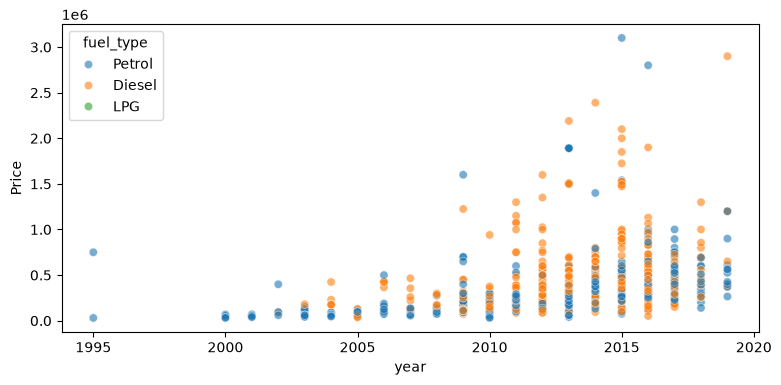

In [4]:
# one listing sits near 85 lakh and drags the line; drop it
df = df[df["Price"] < 6e6].reset_index(drop=True)

plt.figure(figsize=(9, 4))
sns.scatterplot(data=df, x="year", y="Price", hue="fuel_type", alpha=0.6)
plt.show()

In [5]:
X = df[["name", "company", "year", "kms_driven", "fuel_type"]]
y = df["Price"]

ct = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), ["name", "company", "fuel_type"]),
    remainder="passthrough",
)
pipe = make_pipeline(ct, LinearRegression())

Reporting a single train/test R2 here is misleading because the score swings a
lot with the split (searching random states for the best one is just cherry
picking). 5-fold CV gives a fairer number.

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
r2 = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
print(f"CV R2: {r2.mean():.3f} +/- {r2.std():.3f}")

CV R2: 0.643 +/- 0.104


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f"test R2  {r2_score(y_test, pred):.3f}")
print(f"test MAE Rs {mean_absolute_error(y_test, pred):,.0f}")

test R2  0.573
test MAE Rs 148,129


In [8]:
# random forest for comparison
rf = make_pipeline(ct, RandomForestRegressor(n_estimators=300, random_state=SEED))
print(f"RF CV R2: {cross_val_score(rf, X, y, cv=cv, scoring='r2').mean():.3f}")

RF CV R2: 0.640


In [9]:
pipe.fit(X, y)
with open("../models/car_price_model.pkl", "wb") as f:
    pickle.dump(pipe, f)

example = pd.DataFrame([{"name": "Maruti Suzuki Swift", "company": "Maruti",
                        "year": 2019, "kms_driven": 40000, "fuel_type": "Petrol"}])
print(f"predicted: Rs {pipe.predict(example)[0]:,.0f}")

predicted: Rs 417,557
